In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score,
                             precision_score, recall_score)
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

DATASET_PATH = r"C:\Users\User\plantvillage\plantvillage dataset\color"
IMG_SIZE     = (128, 128)
BATCH_SIZE   = 32
SEED         = 42

with open("class_names.json") as f:
    class_names = json.load(f)
NUM_CLASSES = len(class_names)

print(f"Classes: {NUM_CLASSES}")
print("Imports successful ✓")

Classes: 38
Imports successful ✓


In [2]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="data_augmentation")

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH, validation_split=0.2, subset="training",
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='categorical')

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH, validation_split=0.2, subset="validation",
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode='categorical')

val_batches = tf.data.experimental.cardinality(val_test_ds) // 2
val_ds      = val_test_ds.take(val_batches)
test_ds     = val_test_ds.skip(val_batches)

AUTOTUNE = tf.data.AUTOTUNE

test_ds_final = (test_ds
    .map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))

# Load saved models
cnn_model       = keras.models.load_model("cnn_best.keras")
mobilenet_model = keras.models.load_model("mobilenet_best.keras")

print("Models loaded ✓")
print(f"CNN:        {cnn_model.name}")
print(f"MobileNetV2: {mobilenet_model.name}")

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Models loaded ✓
CNN:        custom_cnn
MobileNetV2: mobilenetv2_transfer


In [3]:
print("Rebuilding Logistic Regression on sampled data...")

raw_train = train_ds.map(lambda x, y: (normalization_layer(x), y))
raw_test  = test_ds.map(lambda x, y: (normalization_layer(x), y))

X_train, y_train = [], []
X_test,  y_test  = [], []

for i, (images, labels) in enumerate(raw_train):
    if i >= 50: break
    X_train.append(images.numpy().reshape(len(images), -1))
    y_train.append(np.argmax(labels.numpy(), axis=1))

for i, (images, labels) in enumerate(raw_test):
    if i >= 10: break
    X_test.append(images.numpy().reshape(len(images), -1))
    y_test.append(np.argmax(labels.numpy(), axis=1))

X_train = np.vstack(X_train)
y_train = np.concatenate(y_train)
X_test  = np.vstack(X_test)
y_test  = np.concatenate(y_test)

lr_model = LogisticRegression(max_iter=100, solver='saga', n_jobs=-1, random_state=SEED)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("Logistic Regression ready ✓")

Rebuilding Logistic Regression on sampled data...
Logistic Regression ready ✓


In [4]:
print("Getting predictions from all models...")

# CNN predictions
y_true_cnn, y_pred_cnn = [], []
for images, labels in test_ds_final:
    preds = cnn_model.predict(images, verbose=0)
    y_pred_cnn.extend(np.argmax(preds, axis=1))
    y_true_cnn.extend(np.argmax(labels.numpy(), axis=1))

y_true_cnn = np.array(y_true_cnn)
y_pred_cnn = np.array(y_pred_cnn)

# MobileNetV2 predictions
y_true_mn, y_pred_mn = [], []
for images, labels in test_ds_final:
    preds = mobilenet_model.predict(images, verbose=0)
    y_pred_mn.extend(np.argmax(preds, axis=1))
    y_true_mn.extend(np.argmax(labels.numpy(), axis=1))

y_true_mn = np.array(y_true_mn)
y_pred_mn = np.array(y_pred_mn)

print("Predictions ready ✓")
print(f"Test samples: {len(y_true_mn)}")

Getting predictions from all models...
Predictions ready ✓
Test samples: 5421


In [5]:
def print_report(y_true, y_pred, model_name):
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='weighted')
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  Precision : {prec*100:.2f}%")
    print(f"  Recall    : {rec*100:.2f}%")
    print(f"  F1 Score  : {f1*100:.2f}%")
    print(f"{'='*50}")
    return acc, prec, rec, f1

lr_acc,  lr_prec,  lr_rec,  lr_f1  = print_report(y_test,     lr_preds,   "Logistic Regression")
cnn_acc, cnn_prec, cnn_rec, cnn_f1 = print_report(y_true_cnn, y_pred_cnn, "Custom CNN")
mn_acc,  mn_prec,  mn_rec,  mn_f1  = print_report(y_true_mn,  y_pred_mn,  "MobileNetV2")


  Logistic Regression
  Accuracy  : 51.56%
  Precision : 53.83%
  Recall    : 51.56%
  F1 Score  : 50.67%

  Custom CNN
  Accuracy  : 33.20%
  Precision : 38.54%
  Recall    : 33.20%
  F1 Score  : 31.91%

  MobileNetV2
  Accuracy  : 67.88%
  Precision : 70.32%
  Recall    : 67.88%
  F1 Score  : 67.01%


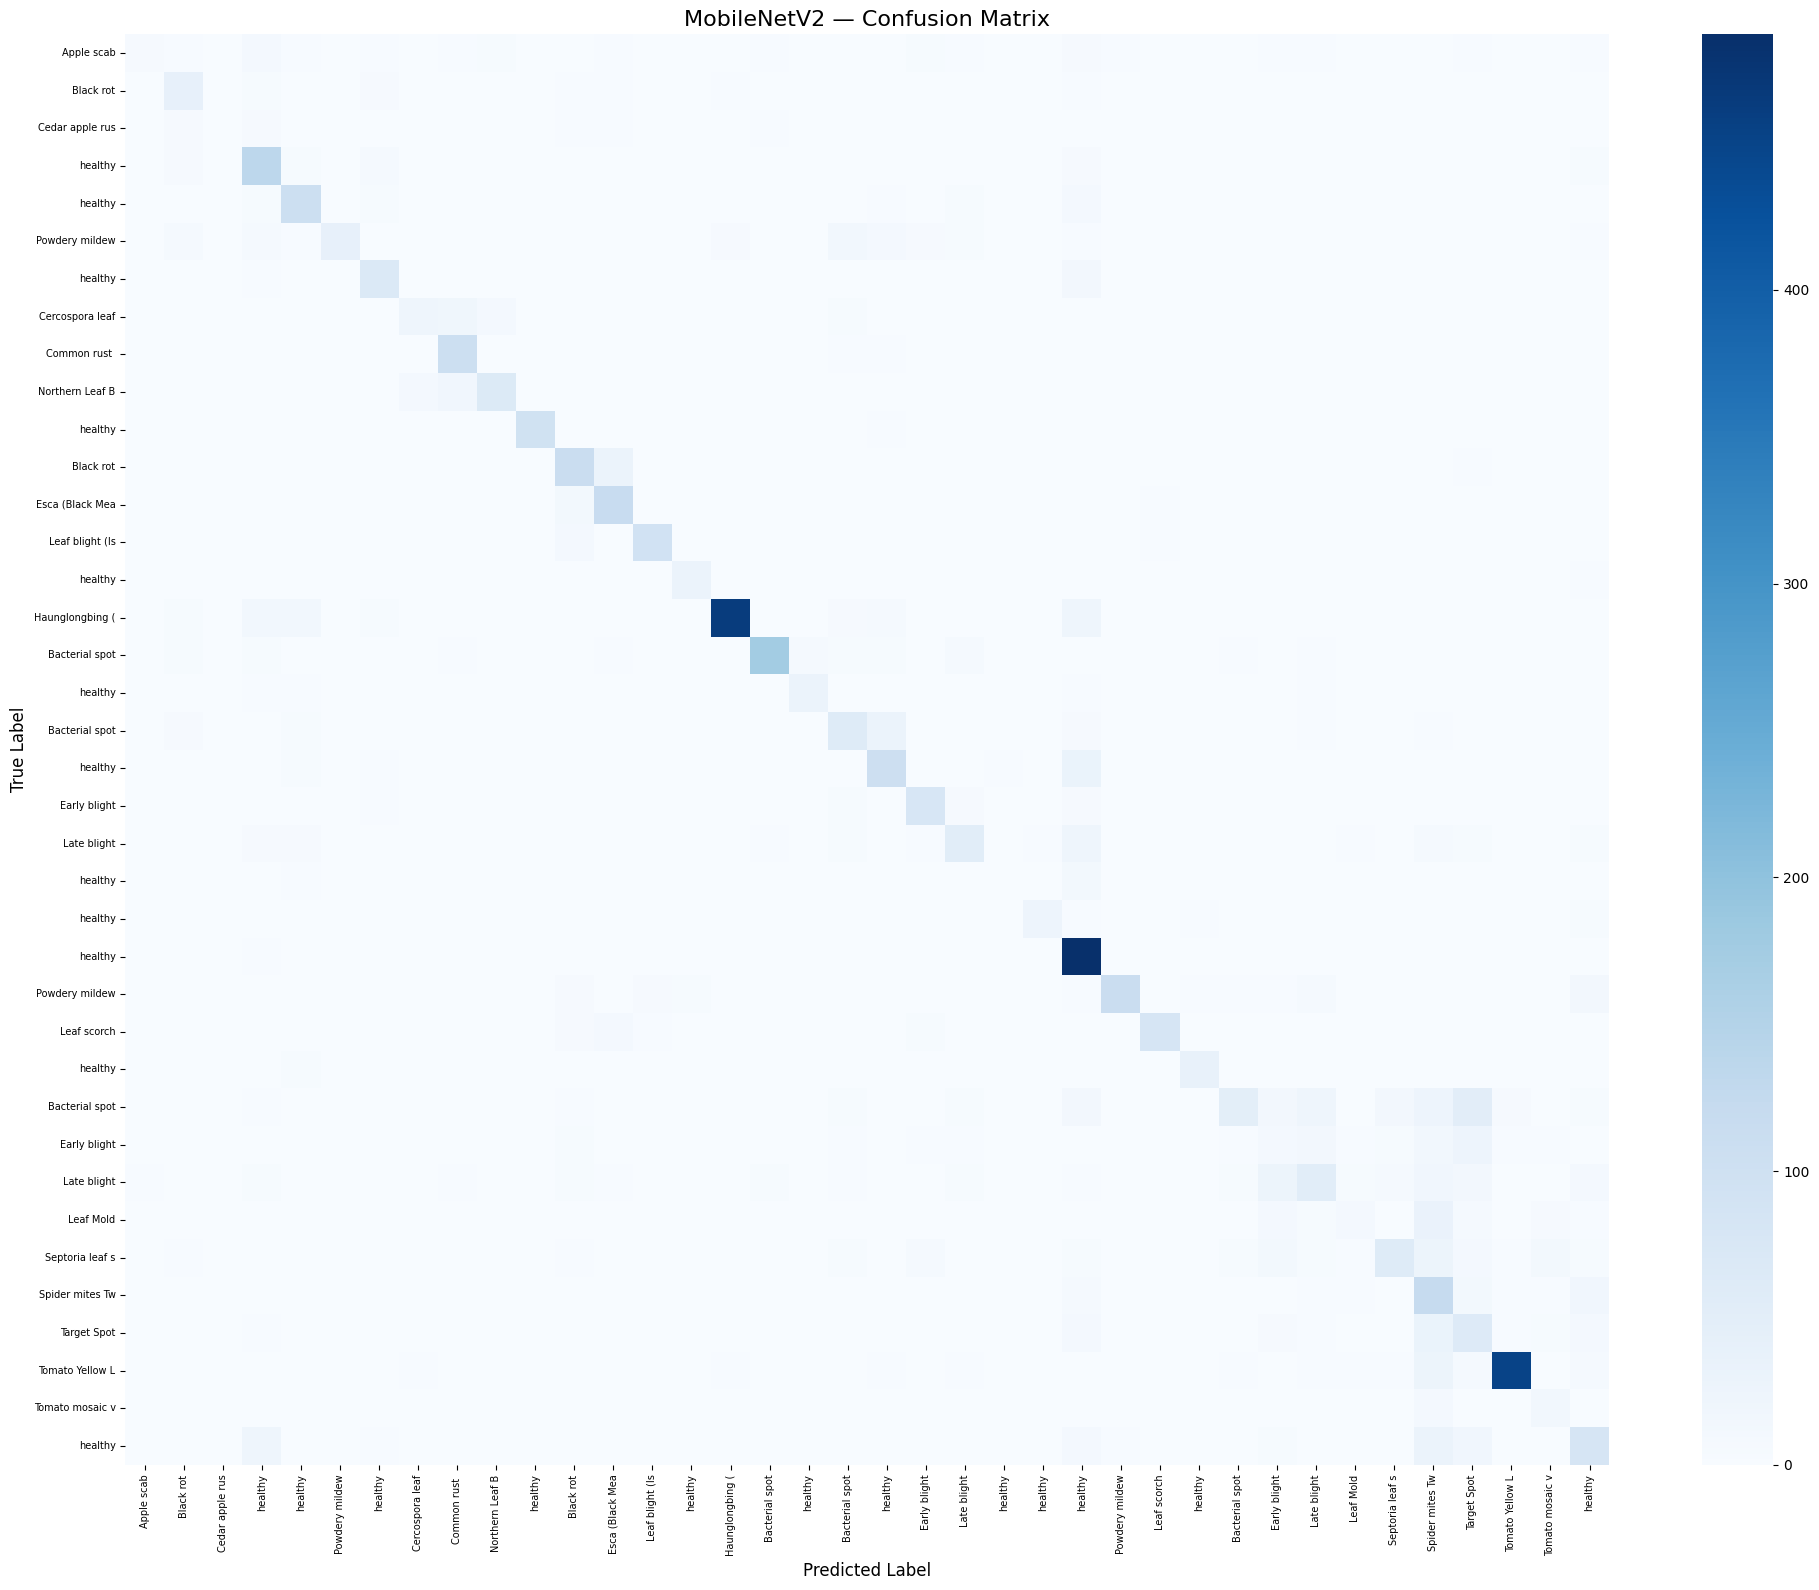

Confusion matrix saved ✓


In [6]:
cm = confusion_matrix(y_true_mn, y_pred_mn)

# Use short class names for readability
short_names = [c.split("___")[-1].replace("_", " ")[:15] for c in class_names]

plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=short_names,
            yticklabels=short_names)
plt.title("MobileNetV2 — Confusion Matrix", fontsize=16)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig("confusion_matrix_mobilenet.png", dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved ✓")

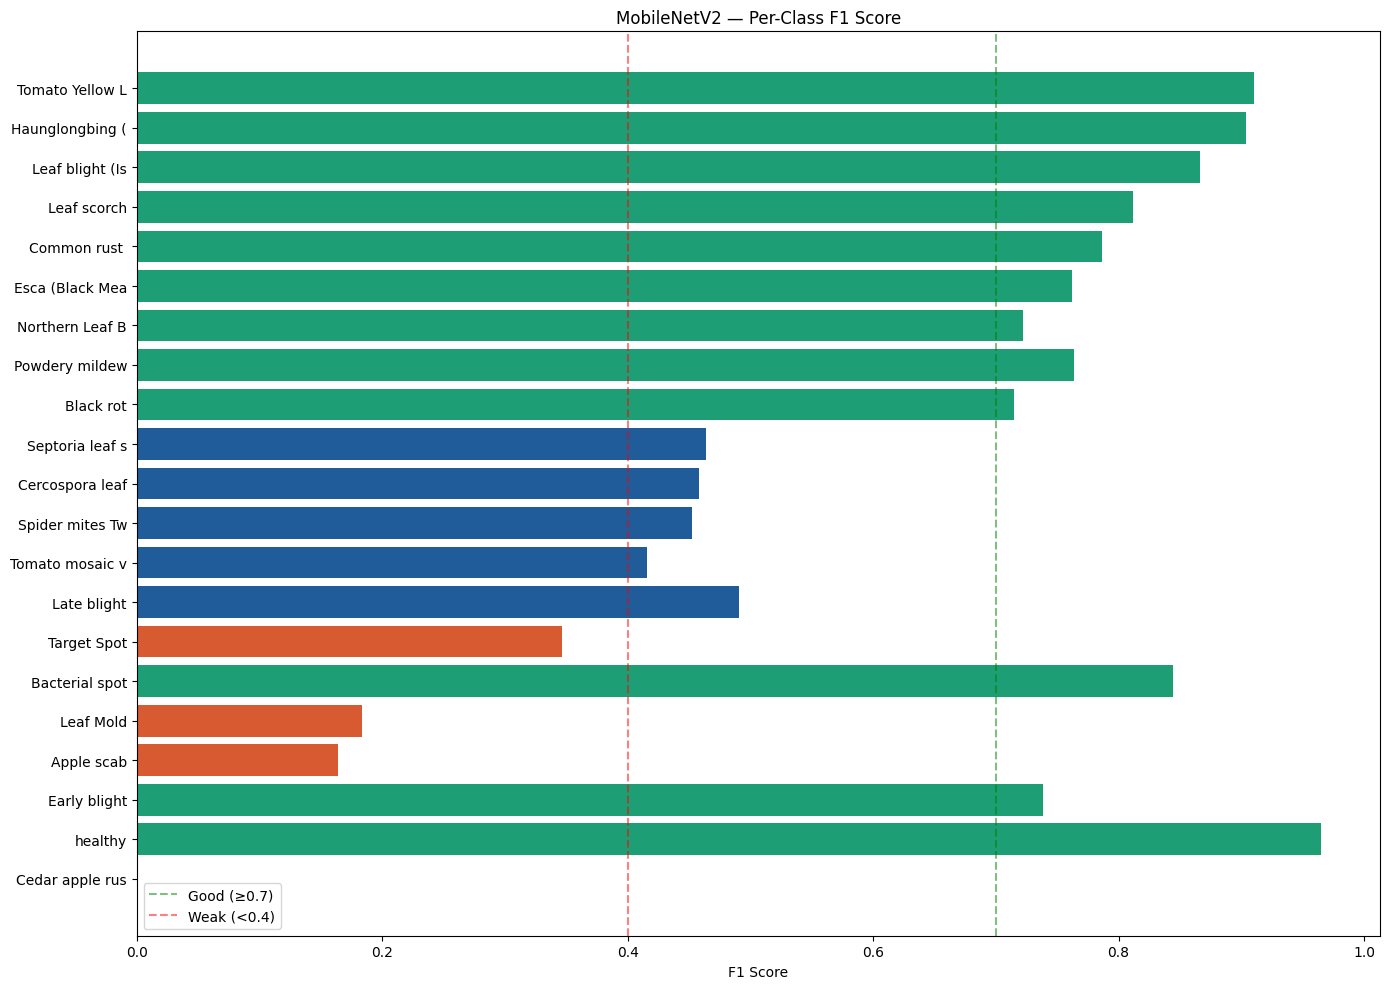

In [7]:
# Per-class F1 for MobileNetV2
f1_per_class = f1_score(y_true_mn, y_pred_mn, average=None)
sorted_idx   = np.argsort(f1_per_class)

short_names_arr = np.array(short_names)
colors = ['#1d9e75' if f >= 0.7 else '#d85a30' if f < 0.4 else '#1F5C99'
          for f in f1_per_class[sorted_idx]]

plt.figure(figsize=(14, 10))
plt.barh(short_names_arr[sorted_idx], f1_per_class[sorted_idx], color=colors)
plt.axvline(x=0.7, color='green',  linestyle='--', alpha=0.5, label='Good (≥0.7)')
plt.axvline(x=0.4, color='red',    linestyle='--', alpha=0.5, label='Weak (<0.4)')
plt.xlabel("F1 Score")
plt.title("MobileNetV2 — Per-Class F1 Score")
plt.legend()
plt.tight_layout()
plt.savefig("f1_per_class.png", dpi=150, bbox_inches='tight')
plt.show()

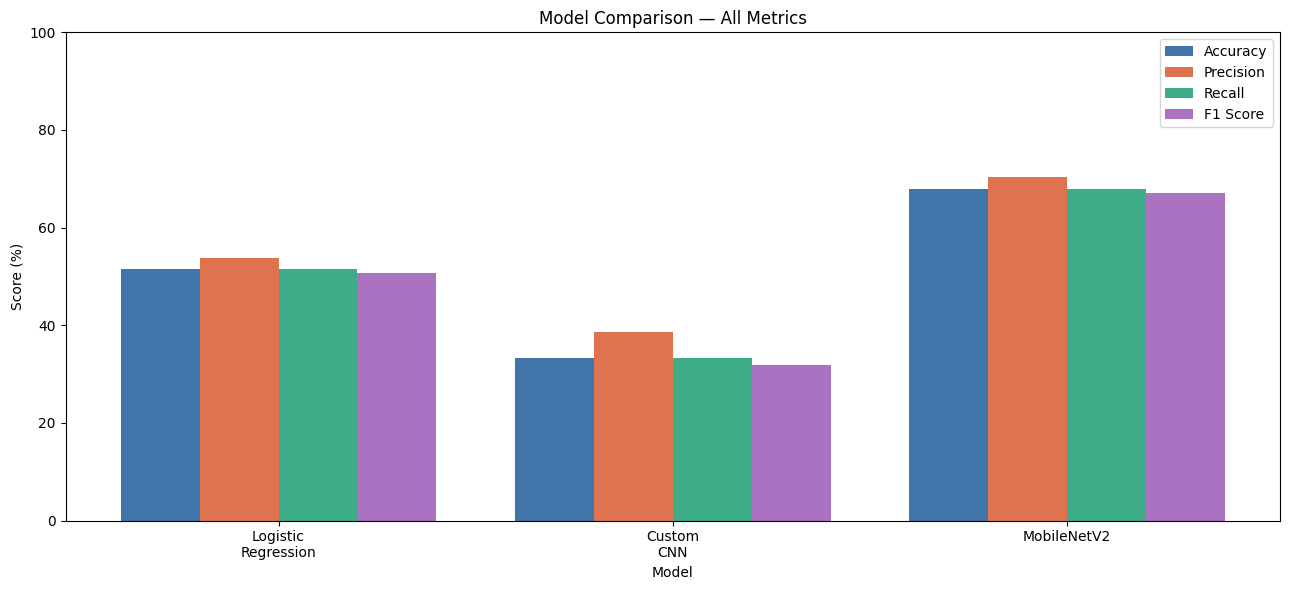


Evaluation complete ✓
Best model: MobileNetV2 with 67.88% accuracy
Saved eval_results.json ✓


In [8]:
models  = ['Logistic\nRegression', 'Custom\nCNN', 'MobileNetV2']
metrics = {
    'Accuracy':  [lr_acc,  cnn_acc,  mn_acc],
    'Precision': [lr_prec, cnn_prec, mn_prec],
    'Recall':    [lr_rec,  cnn_rec,  mn_rec],
    'F1 Score':  [lr_f1,   cnn_f1,   mn_f1]
}

x     = np.arange(len(models))
width = 0.2
colors = ['#1F5C99', '#d85a30', '#1d9e75', '#9b59b6']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (metric, values) in enumerate(metrics.items()):
    ax.bar(x + i*width, [v*100 for v in values],
           width, label=metric, color=colors[i], alpha=0.85)

ax.set_xlabel('Model')
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison — All Metrics')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# Save full evaluation results
eval_results = {
    "logistic_regression": {"accuracy": round(lr_acc*100,2),  "f1": round(lr_f1*100,2)},
    "custom_cnn":          {"accuracy": round(cnn_acc*100,2), "f1": round(cnn_f1*100,2)},
    "mobilenetv2":         {"accuracy": round(mn_acc*100,2),  "f1": round(mn_f1*100,2)},
    "best_model":          "mobilenetv2"
}
with open("eval_results.json", "w") as f:
    json.dump(eval_results, f, indent=2)

print("\nEvaluation complete ✓")
print(f"Best model: MobileNetV2 with {mn_acc*100:.2f}% accuracy")
print("Saved eval_results.json ✓")